# UNIVERSIDAD ICESI
# MAESTRIA EN  IA APLICADA
# Trabajo 3
## Nombres:

#### Diego Agudelo
#### Angelica Maria Mayor
#### Freddy Mauricio Gutierrez
#### Carlos Alberto Martinez Ramirez
#### Wilman Quiñonez


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/11a21biJCLm4cuIX89JsYWs-btMP_mLfz?usp=sharing)

En este notebook implementaremos un clasificador de comentarios de amazon en español utilizando la arquitectura de red Transformers. Utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

El dataset contiene lo siguiente:


| Propiedad              | Descripción                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **`review_id`**         | Identificador único de la reseña.                                           |
| **`reviewer_id`**       | Identificador del usuario que dejó la reseña.                              |
| **`review_title`**      | Título de la reseña escrito por el usuario.                                |
| **`review_body`**       | Texto completo de la reseña (contenido principal).                         |
| **`star_rating`**       | Puntuación otorgada por el usuario, en una escala de 1 a 5 estrellas.      |
| **`language`**          | Idioma de la reseña (en este caso siempre `"es"` para español).            |
| **`product_category`**  | Categoría del producto reseñado (ej: libros, electrónica, hogar, etc.).    |
| **`review_date`**       | Fecha en que se dejó la reseña.                                            |

📐 **Tamaño aproximado**  
La versión multilingüe del dataset contiene millones de reseñas en varios idiomas.  
La partición en español (`"es"`) incluye **cientos de miles de reseñas reales** de productos de Amazon en distintas categorías, lo que la convierte en una muestra suficientemente grande y variada para tareas de clasificación y modelado de lenguaje en español.  



##1. Configuración e Instalación

In [1]:
# Ahora vamos a crear nuestro implementación de clasificador de reseñas de Amazon en español
# Basándonos en la estructura del archivo adjunto pero adaptándolo para el dataset de Amazon

# Primero instalamos las dependencias necesarias
import sys
import subprocess

def install_packages():
    packages = [
        'torch',
        'transformers',
        'autokeras',
        'tensorflow',
        'datasets',
        'tokenizers',
        'scikit-learn',
        'matplotlib',
        'seaborn',
        'optuna',
        'pandas',
        'numpy',
        'tqdm',
        'os',
        're'
    ]

    for package in packages:
        try:
            __import__(package)
            print(f"✓ {package} ya está instalado")
        except ImportError:
            print(f"Instalando {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_packages()



✓ torch ya está instalado
✓ transformers ya está instalado
Instalando autokeras...
✓ tensorflow ya está instalado
✓ datasets ya está instalado
✓ tokenizers ya está instalado
Instalando scikit-learn...
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
Instalando optuna...
✓ pandas ya está instalado
✓ numpy ya está instalado
✓ tqdm ya está instalado
✓ os ya está instalado
✓ re ya está instalado


##1.1. Importación de Librerías

In [2]:
# Importaciones principales
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import optuna
import pandas as pd
import pkg_resources
import random
import re
import seaborn as sns
import subprocess
import sys
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import warnings

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode
from typing import Optional, Tuple
from tensorflow import keras

warnings.filterwarnings('ignore')

print("Dependencias cargadas correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Número de GPUs: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo seleccionado: {device}")


/tmp/ipython-input-1243843228.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Dependencias cargadas correctamente
PyTorch version: 2.8.0+cu126
CUDA disponible: True
Número de GPUs: 1
Dispositivo seleccionado: cuda


In [3]:
# Ignorar advertencias para evitar que el output se llene de mensajes innecesarios
warnings.filterwarnings("ignore")

# Desactivar el paralelismo en los tokenizadores de Hugging Face para evitar conflictos
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Ignorar advertencias (repetido para asegurar que todas las advertencias sean ignoradas)
warnings.filterwarnings('ignore')

# Función para establecer una semilla y garantizar la reproducibilidad de los resultados
def set_seed(seed):
    torch.manual_seed(seed)  # Semilla para PyTorch en la CPU
    torch.cuda.manual_seed_all(seed)  # Semilla para PyTorch en todas las GPUs
    np.random.seed(seed)  # Semilla para NumPy
    random.seed(seed)  # Semilla para el módulo random de Python
    torch.backends.cudnn.deterministic = True  # Hacer que las operaciones de cuDNN sean deterministas
    torch.backends.cudnn.benchmark = False  # Desactivar el benchmarking de cuDNN para mejorar la reproducibilidad

# Establecer la semilla en 42 para garantizar resultados reproducibles
set_seed(42)

# Crear una lista de todos los paquetes instalados en el entorno actual
installed_packages = [package.key for package in pkg_resources.working_set]

# Verificar si el código se está ejecutando en Google Colab
IN_COLAB = 'google-colab' in installed_packages


In [4]:
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,961 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,790 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [

##1.2. Cargando el dataset
Este es un dataset pequeño de reseñas de productos en español con sus respectivas categorías representado por estrellas. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [5]:
# Cargar dataset
from datasets import load_dataset

def load_spanish_news_dataset_train():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='train')

# 2. Cargar el dataset_test
def load_spanish_news_dataset_test():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='test')

# 3. Cargar el dataset de validación
def load_spanish_news_dataset_valid():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='validation')

print("Cargando dataset de entrenamiento...")
dataset = load_spanish_news_dataset_train()
dataset = dataset.shuffle(seed=42)

print("Cargando dataset de test...")
dataset_test = load_spanish_news_dataset_test()
dataset_test = dataset_test.shuffle(seed=42)

print("Cargando dataset de validación...")
dataset_valid = load_spanish_news_dataset_valid()
dataset_valid = dataset_valid.shuffle(seed=42)

# Acceder a un ejemplo de la división de entrenamiento
print("Observando un ejemplo del dataset:")
example = dataset[0]
print(example)

Cargando dataset de entrenamiento...


README.md: 0.00B [00:00, ?B/s]

es/train-00000-of-00001.parquet:   0%|          | 0.00/25.2M [00:00<?, ?B/s]

es/validation-00000-of-00001.parquet:   0%|          | 0.00/627k [00:00<?, ?B/s]

es/test-00000-of-00001.parquet:   0%|          | 0.00/631k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Cargando dataset de test...
Cargando dataset de validación...
Observando un ejemplo del dataset:
{'review_title': '.', 'review_body': 'La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente.', 'review_id': 'es_0614019', 'stars': 3}


In [6]:
print(dataset)

Dataset({
    features: ['review_title', 'review_body', 'review_id', 'stars'],
    num_rows: 200000
})


Para los efectos de esta tarea, nos servirán el review_body y stars naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

In [7]:
%%time
from datasets import load_dataset

# Load all splits of the dataset
print("Cargando datasets (train, test, validation)...")
dataset_splits = {
    'train': dataset,
    'test': dataset_test,
    'validation': dataset_valid
}
print("Datasets cargados.")

def analyze_text_lengths(dataset_split, split_name):
    """Calcula y muestra las longitudes de texto para un split del dataset."""
    print(f"\nAnalizando longitudes de texto para el split: {split_name}")

    # Calculate lengths for both 'review_title' and 'review_body' and combine them
    text_lengths = [len(row['review_title']) + len(row['review_body']) for row in dataset_split]

    if text_lengths:
        print(f"Texto más corto: {min(text_lengths)}")
        print(f"Texto más largo: {max(text_lengths)}")
        print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.2f}")
    else:
        print("No hay datos en este split para analizar.")

# Analyze each split
for split_name, dataset_split in dataset_splits.items():
    analyze_text_lengths(dataset_split, split_name)

Cargando datasets (train, test, validation)...
Datasets cargados.

Analizando longitudes de texto para el split: train
Texto más corto: 20
Texto más largo: 3160
Longitud promedio: 170.47

Analizando longitudes de texto para el split: test
Texto más corto: 22
Texto más largo: 1816
Longitud promedio: 171.08

Analizando longitudes de texto para el split: validation
Texto más corto: 22
Texto más largo: 1616
Longitud promedio: 169.40
CPU times: user 26.7 s, sys: 112 ms, total: 26.8 s
Wall time: 41.4 s


Estos valores ofrecen un panorama general del comportamiento de los textos. Como se observa, existe una gran variabilidad en los datos; por ello, resulta necesario profundizar en el análisis con el fin de determinar con mayor precisión el tamaño de los textos que se utilizarán.

##2. Limpieza de Texto y Tokenización
Implementamos una función de limpieza para eliminar ruido del texto. Luego, usamos un tokenizador de Hugging Face para convertir el texto en secuencias de tokens.

In [8]:
# Función de limpieza de texto
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Eliminar etiquetas HTML
    text = re.sub(r'https?://\S+', '', text)  # Eliminar URLs
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]', '', text)  # Eliminar caracteres especiales y números
    text = text.lower()  # Convertir a minúsculas
    return text

def preprocess_text(text):
    return text.lower().replace("<br />", " ").strip()

In [9]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': preprocess_text(example['review_body'])})

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

CPU times: user 31 s, sys: 232 ms, total: 31.3 s
Wall time: 50.6 s


In [10]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': clean_text(example['review_body'])})

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

CPU times: user 14.8 s, sys: 132 ms, total: 15 s
Wall time: 15.1 s


##2.1. Análisis de la longitud de los reviews en los conjuntos de train, test y validation

Se realizó un análisis de la longitud de los reviews en los tres conjuntos de datos (entrenamiento, prueba y validación) con el objetivo de definir un valor adecuado para el parámetro seq_length. Los resultados muestran que las distribuciones de los tres conjuntos presentan comportamientos similares, aunque con la presencia de numerosos valores atípicos asociados a reseñas especialmente largas.

Como era de esperarse, los percentiles del conjunto de entrenamiento son más altos debido a que contiene un mayor número de observaciones. Sin embargo, en términos generales, el análisis permite comprender la cantidad de información que se incluirá en el modelo y balancear el uso de padding. El objetivo es seleccionar un tamaño de secuencia que capture la mayoría de los reviews sin recortar excesivamente las reseñas largas ni introducir un exceso de padding en las más cortas.

A conutinuación y basados en los resultados obtenidos se propone usar un **max_length=81**.

In [11]:
text_lengths = [len(row['review_body'].split()) for row in dataset]

import plotly.express as px
fig = px.box(
    x=text_lengths,  # eje horizontal con las longitudes
    orientation="h", # orientación horizontal del boxplot
    labels={"x": "Longitud de reseña (tokens) "}, # etiqueta para el eje X
    title="Distribución de longitudes de reseñas (tokens) Train" # título del gráfico
)

# Mostrar el gráfico
fig.show()

In [12]:
text_lengths = [len(row['review_body'].split()) for row in dataset_test]

import plotly.express as px
fig = px.box(
    x=text_lengths,  # eje horizontal con las longitudes
    orientation="h", # orientación horizontal del boxplot
    labels={"x": "Longitud de reseña (tokens)"}, # etiqueta para el eje X
    title="Distribución de longitudes de reseñas (tokens) Test" # título del gráfico
)

# Mostrar el gráfico
fig.show()

In [13]:
text_lengths = [len(row['review_body'].split()) for row in dataset_valid]

import plotly.express as px
fig = px.box(
    x=text_lengths,  # eje horizontal con las longitudes
    orientation="h", # orientación horizontal del boxplot
    labels={"x": "Longitud de reseña (tokens)"}, # etiqueta para el eje X
    title="Distribución de longitudes de reseñas (tokens) Validation" # título del gráfico
)

# Mostrar el gráfico
fig.show()

##2.2. Análisis de palabras únicas en todo el dataset

En este ejercicio solamente se usaron las palabras contenidas en el dataset de entrenamiento, teniendo un total de **88970** palabras únicas, este valor nos permite ajustar adecuadamente el valor del vocabulario a definir en el tokenizador. Se definio un vocabulario de **50000** tokens.

In [14]:
# Importa la clase Counter del módulo collections, que es una subclase de diccionario
# utilizada para contar objetos hasheables (como palabras).
from collections import Counter
# Importa la función tqdm, que sirve para mostrar una barra de progreso
# en bucles iterables. Es útil para visualizar el avance en tareas largas.
from tqdm import tqdm

# Inicializa un objeto de la clase Counter. Este objeto se comportará como un diccionario
# donde las claves serán los tokens (palabras) y los valores serán sus frecuencias.
token_counts = Counter()

# La línea 'for row in tqdm(dataset, desc="Procesando reseñas"):' itera sobre
# cada fila (o 'row') de una variable llamada 'dataset' (que debe ser un iterable
# como una lista de diccionarios o un DataFrame de pandas).
# La función 'tqdm' envuelve el iterable 'dataset' para generar una barra de progreso.
# El parámetro 'desc' añade una descripción a la barra de progreso, en este caso,
# "Procesando reseñas".
for row in tqdm(dataset, desc="Procesando reseñas"):
    # Concatena las cadenas de texto asociadas a las claves 'review_title' y 'review_body'
    # de cada fila, las une con un espacio y convierte todo a minúsculas para
    # asegurar que las palabras como "Bueno" y "bueno" se cuenten como el mismo token.
    text = (row['review_title'] + " " + row['review_body']).lower()

    # Divide la cadena de texto 'text' en una lista de palabras (tokens) utilizando
    # los espacios en blanco como delimitadores. Esto crea una lista de palabras.
    tokens = text.split()

    # Actualiza el objeto Counter 'token_counts' con los nuevos tokens encontrados.
    # El método 'update' incrementa el recuento de los tokens que ya existen
    # y añade los nuevos con un recuento inicial de 1.
    token_counts.update(tokens)

# La función len() se usa para obtener el número de elementos en el objeto Counter.
# En este caso, devuelve el número de claves únicas, que corresponde al número
# total de palabras únicas que se encontraron en todo el dataset.
num_unique_words = len(token_counts)

# Imprime una cadena de texto que incluye el valor de 'num_unique_words',
# mostrando el recuento total de palabras únicas.
print("Palabras únicas en el dataset:", num_unique_words)

# Imprime una cadena de texto para introducir la siguiente línea de salida.
print("Ejemplos de tokens y sus recuentos:")

# La función list() convierte el objeto 'token_counts.items()' en una lista.
# El método .items() devuelve una vista de los pares (token, recuento).
# El slicing '[:20]' limita la lista a los primeros 20 pares.
# Esto es útil para mostrar un ejemplo del contenido del contador sin imprimir todo.
print(list(token_counts.items())[:20])

Procesando reseñas: 100%|██████████| 200000/200000 [00:11<00:00, 17559.69it/s]

Palabras únicas en el dataset: 88970
Ejemplos de tokens y sus recuentos:
[('.', 676), ('la', 186300), ('montarlo', 457), ('se', 95980), ('rompió', 1752), ('una', 46252), ('rueda', 548), ('debido', 764), ('a', 81502), ('materiales', 1921), ('débiles', 131), ('pero', 70018), ('al', 33505), ('arreglarla', 20), ('funciona', 14167), ('correctamente', 2537), ('primeras', 337), ('impresiones', 67), ('el', 173577), ('servicio', 2479)]



##2.3. Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Para ahorrarnos tiempo, vamos a entrenar uno basado en **dccuchile/bert-base-spanish-wwm-uncased**, ajustado a nuestro dataset. Para ello, debemos seleccionar una muestra representativa de nuestro dataset, como no es muy grande, casi que podemos usarlo todo. Luego, debemos definir el tamaño del vocabulario, es decir, cuantos tokens únicos queremos soportar en nuestro tokenizador. Para que un modelo de lenguaje funcione moderadamente bien para una tarea de clasificación, considerando el tamaño de nuestro corpus, deberíamos definir unos **50000** tokens.

In [15]:
%%time
# Inicializar el tokenizador
model_name = "dccuchile/bert-base-spanish-wwm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
length = 200000
iter_dataset = iter(dataset)
byte_to_unicode_map = bytes_to_unicode()
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
base_vocab = list(unicode_to_byte_map.keys())


def batch_iterator(batch_size: int = 10):
    for _ in tqdm(range(0, length, batch_size)):
        yield [next(iter_dataset)['review_body'] for _ in range(batch_size)]

spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab)

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

100%|██████████| 20000/20000 [00:23<00:00, 859.91it/s] 


CPU times: user 22.4 s, sys: 126 ms, total: 22.6 s
Wall time: 25.2 s


In [16]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['[MASK]', '[PAD]', '[UNK]', '[CLS]', '[SEP]', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*']
15 tokens de en medio:
['tras', 'sea', '##jas', 'can', '##tras', '##ren', '##dí', 'vis', 'espa', 'poder', '##ban', 'diseño', 'pod', 'tienes', 'mí']
Últimos 15 tokens:
['scaner', 'scanear', 'wmv', 'worten', 'wilson', 'williams', '##utsche', '##stone', 'escarmentado', 'esceptica', 'untuoso', 'untuosidad', 'conducta', 'concertado', 'comifort']


In [17]:
spanish_news_tokenizer.pad_token = '[PAD]'
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length',return_token_type_ids=False)


{'input_ids': [3, 2202, 2387, 5, 4, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 0, 0, 0]}

In [18]:
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length').tokens()


['[CLS]', 'hola', 'mundo', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

In [19]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class SpanishNewsDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = '[PAD]'
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['stars'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['review_body'], self.dataset[index]['stars']
        y = self.class_2_id_map[y]
        data = {k: torch.tensor(v) for k, v in self.tokenizer(text, max_length=self.seq_length, truncation=True, padding='max_length').items()}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

Basado en el análisis descriptivo de los texto se propone usar un **seq_length=81**.

In [20]:
max_len = 81
spanish_news_dataset_train = SpanishNewsDataset(spanish_news_tokenizer, dataset, seq_length=max_len)
assert len(spanish_news_dataset_train) == len(dataset)

spanish_news_dataset_test= SpanishNewsDataset(spanish_news_tokenizer, dataset_test, seq_length=max_len)
assert len(spanish_news_dataset_test) == len(dataset_test)

spanish_news_dataset_val = SpanishNewsDataset(spanish_news_tokenizer, dataset_valid, seq_length=max_len)
assert len(spanish_news_dataset_val) == len(dataset_valid)

In [21]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

train_loader = DataLoader(spanish_news_dataset_train, batch_size=12, shuffle=True, num_workers=2)
val_loader = DataLoader(spanish_news_dataset_val, batch_size=12, shuffle=False, num_workers=2)
test_loader = DataLoader(spanish_news_dataset_test, batch_size=12, shuffle=False, num_workers=2)

In [22]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)


## Se va a usar un tamaño de 128 para la dimensión del embedding.

In [23]:
emb_dim = 128
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()

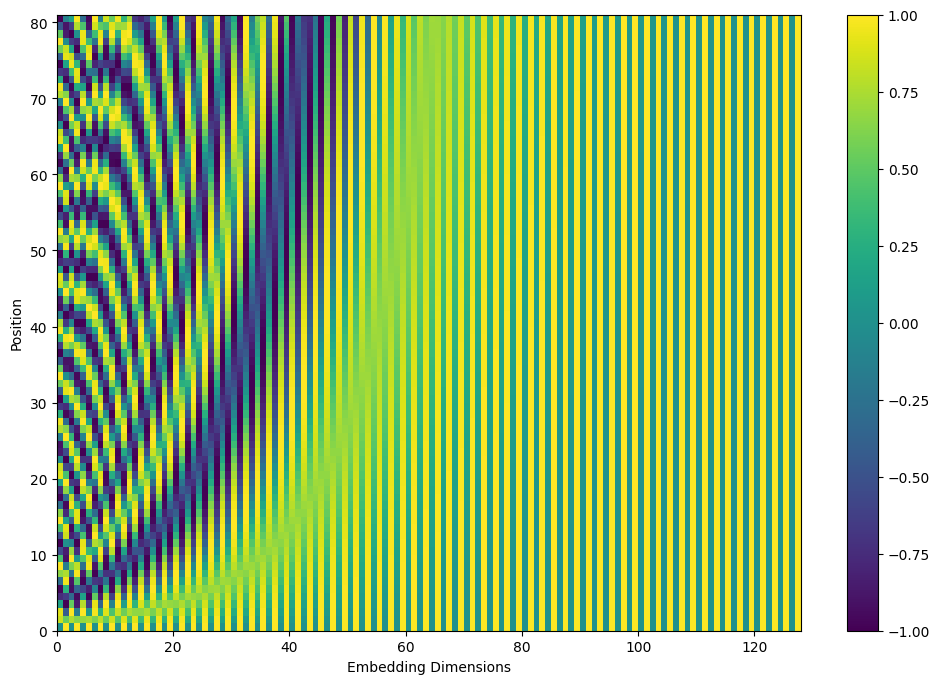

In [24]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [25]:
text = "hola mundo!"
tokens = spanish_news_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 81, 128])

##3. Modelación usando transformers
A continuación se hacen diferentes pruebas paso a paso con el fin de verificar las dimensiones de salida de cada proceso.

In [26]:
import math


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.comibe_heads = nn.Linear(emb_dim, emb_dim)


    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]

        # multiplicacion Q \cdot K^T
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        # escalamiento
        attn_logits = attn_logits / math.sqrt(d_k)

        # Se aplica la máscara
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention


    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x =  x.reshape(batch_size, -1, self.num_heads, self.projection_dim)  # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, emb_dim / num_heads)


    def forward(self, x, mask=None, return_attention=False):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3) # (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output

In [27]:

mha = MultiHeadAttention(emb_dim)
mha(embedding, mask).shape

torch.Size([1, 81, 128])

In [28]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)

In [29]:
tb = TransformerBlock(emb_dim)
tb(embedding, mask).shape

torch.Size([1, 81, 128])

In [30]:
num_heads = 8
vocab_size = spanish_news_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, spanish_news_dataset_train.num_classes)
)

In [31]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape


torch.Size([12, 81, 128])

In [32]:
pred = ff(attention)
pred.shape

torch.Size([12, 5])

##3.1. Modelación usando transformers, corrida CPU

Debido a que el entrenamiento de este tipo de modelos resulta muy costoso computacionalmente, se decidió realizar pruebas iniciales en CPU con Colab, limitando el número de lotes procesados (limit_train_batches=0.1, limit_val_batches=0.25). El objetivo fue comprobar que todo el flujo de entrenamiento funcionara correctamente y obtener resultados preliminares sin requerir una GPU.

En cuanto a la arquitectura, se realizaron dos ajustes principales respecto a la red propuesta en clase:

1- Simplificación de la capa secuencial, dado que la longitud promedio de los textos era relativamente corta y no se justificaba una estructura tan profunda.

2- Eliminación de la capa final LogSoftmax, de modo que el modelo ahora produce logits crudos como salida. Esta modificación garantiza que la función de pérdida (cross_entropy) procese las predicciones de manera adecuada, siguiendo la convención estándar en PyTorch: logits → cross_entropy → probabilidades implícitas por clase.

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class SpanishNewsClassifier(LightningModule):
    def __init__(self, max_len, vocab_size, num_classes, emb_dim, num_heads=4, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)  # 1 bloque, 4 heads

        self.head = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)   # logits
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc   = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc  = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x, mask=None):
        x = self.token_embeddings(x)           # [B, L, D]
        x = self.transformer(x, mask)          # [B, L, D]
        if mask is not None:
            lengths = mask.sum(dim=1, keepdim=True).clamp(min=1)
            x = (x * mask.unsqueeze(-1)).sum(dim=1) / lengths  # mean pooling
        else:
            x = x.mean(dim=1)
        return self.head(x)                    # [B, C] logits

    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log('train-loss', loss, prog_bar=True, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log('val-loss', loss, prog_bar=True, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_epoch=True)

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        logits = self(x, mask)
        self.test_acc(logits, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)


In [35]:
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, Callback
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

seed_everything(42)

# Callback personalizado para mostrar métricas durante el entrenamiento
class MetricsDisplayCallback(Callback):
    def __init__(self):
        self.metrics_history = defaultdict(list)

    def on_train_epoch_end(self, trainer, pl_module):
        # Obtener métricas actuales
        current_metrics = trainer.callback_metrics

        # Mostrar progreso de entrenamiento
        epoch = trainer.current_epoch
        print(f"\n{'='*60}")
        print(f"ÉPOCA {epoch + 1}/{trainer.max_epochs}")
        print(f"{'='*60}")

        # Mostrar métricas de entrenamiento
        if 'train-loss' in current_metrics:
            train_loss = current_metrics['train-loss'].item()
            print(f"📈 Train Loss: {train_loss:.4f}")
            self.metrics_history['train_loss'].append(train_loss)

        if 'train-acc' in current_metrics:
            train_acc = current_metrics['train-acc'].item()
            print(f"🎯 Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
            self.metrics_history['train_acc'].append(train_acc)

        # Mostrar métricas de validación
        if 'val-loss' in current_metrics:
            val_loss = current_metrics['val-loss'].item()
            print(f"📉 Val Loss: {val_loss:.4f}")
            self.metrics_history['val_loss'].append(val_loss)

        if 'val-acc' in current_metrics:
            val_acc = current_metrics['val-acc'].item()
            print(f"🏆 Val Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
            self.metrics_history['val_acc'].append(val_acc)

            # Mostrar si es el mejor accuracy hasta ahora
            if len(self.metrics_history['val_acc']) > 1:
                best_so_far = max(self.metrics_history['val_acc'])
                if val_acc == best_so_far:
                    print(f"🌟 ¡NUEVO MEJOR ACCURACY DE VALIDACIÓN! 🌟")
                else:
                    print(f"💫 Mejor accuracy hasta ahora: {best_so_far:.4f} ({best_so_far*100:.2f}%)")

        print(f"{'='*60}")

# Instanciar el callback personalizado
metrics_display_callback = MetricsDisplayCallback()

# Modelo con configuración optimizada
model = SpanishNewsClassifier(
    max_len=spanish_news_dataset_train.seq_length,
    vocab_size=spanish_news_tokenizer.vocab_size,
    num_classes=spanish_news_dataset_train.num_classes,
    emb_dim=emb_dim,
    num_heads=8,
)

tb_logger = TensorBoardLogger("tb_logs", name="TransformersClassifier_cpu_optimized")

# Callbacks mejorados
callbacks = [
    metrics_display_callback,  # Nuestro callback personalizado
    EarlyStopping(
        monitor="val-acc",
        patience=7,                    # Más paciencia para mejor convergencia
        mode="max",
        verbose=True,
        min_delta=0.001               # Mejora mínima requerida
    ),
    ModelCheckpoint(
        monitor="val-acc",
        mode="max",
        save_top_k=3,                 # Guardar los 3 mejores modelos
        save_last=True,
        filename="best-checkpoint-{epoch:02d}-{val-acc:.4f}",
        verbose=True
    )
]

trainer = Trainer(
    accelerator="cuda",
    devices=1,
    max_epochs=50,
    precision=32,
    log_every_n_steps=10,             # Log más frecuente
    enable_progress_bar=True,
    logger=tb_logger,
    callbacks=callbacks,
    enable_checkpointing=True,
    gradient_clip_val=1.0,
    accumulate_grad_batches=2,
    # Configuraciones adicionales para mejor visualización
    enable_model_summary=True,        # Mostrar resumen del modelo
    val_check_interval=1.0,           # Validar al final de cada época
)

print("🚀 INICIANDO ENTRENAMIENTO")
print("="*80)

# Entrenar el modelo
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print("\n" + "🎉" + "="*78 + "🎉")
print("ENTRENAMIENTO COMPLETADO - RESULTADOS FINALES")
print("🎉" + "="*78 + "🎉")

# Resumen de métricas durante el entrenamiento
if hasattr(metrics_display_callback, 'metrics_history'):
    history = metrics_display_callback.metrics_history

    print("\n📊 RESUMEN DE ENTRENAMIENTO:")
    print("-" * 50)

    if 'train_acc' in history:
        train_accs = history['train_acc']
        print(f"🎯 Accuracy de Entrenamiento:")
        print(f"   • Inicial: {train_accs[0]:.4f} ({train_accs[0]*100:.2f}%)")
        print(f"   • Final: {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
        print(f"   • Mejor: {max(train_accs):.4f} ({max(train_accs)*100:.2f}%)")
        print(f"   • Mejora: +{(train_accs[-1] - train_accs[0])*100:.2f}%")

    if 'val_acc' in history:
        val_accs = history['val_acc']
        print(f"\n🏆 Accuracy de Validación:")
        print(f"   • Inicial: {val_accs[0]:.4f} ({val_accs[0]*100:.2f}%)")
        print(f"   • Final: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
        print(f"   • Mejor: {max(val_accs):.4f} ({max(val_accs)*100:.2f}%)")
        print(f"   • Mejora: +{(val_accs[-1] - val_accs[0])*100:.2f}%")

# Evaluación del mejor modelo
print("\n🔍 EVALUACIÓN DEL MEJOR MODELO:")
print("-" * 50)

best_model_path = trainer.checkpoint_callback.best_model_path
if best_model_path:
    print(f"📁 Mejor modelo: {best_model_path}")
    best_model = SpanishNewsClassifier.load_from_checkpoint(best_model_path)

    # Evaluar en validación
    print("\n🧪 Evaluando en conjunto de validación...")
    val_results = trainer.validate(best_model, dataloaders=val_loader)
    if val_results and 'val-acc' in val_results[0]:
        val_accuracy = val_results[0]['val-acc']
        print(f"✅ **ACCURACY EN VALIDACIÓN: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)**")

    # Evaluar en test si existe
    if 'test_loader' in locals():
        print("\n🎯 Evaluando en conjunto de test...")
        test_results = trainer.test(best_model, dataloaders=test_loader)
        if test_results and 'test-acc' in test_results[0]:
            test_accuracy = test_results[0]['test-acc']
            print(f"🎊 **ACCURACY EN TEST: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)**")

# Información adicional del entrenamiento
print(f"\n📈 INFORMACIÓN DEL ENTRENAMIENTO:")
print("-" * 50)
print(f"• Épocas completadas: {trainer.current_epoch + 1}")
print(f"• Mejor métrica de validación: {trainer.checkpoint_callback.best_model_score:.4f}")
print(f"• Modelos guardados: {len(trainer.checkpoint_callback.best_k_models)}")

# Evaluación manual como respaldo
def manual_evaluation_detailed(model, dataloader, dataset_name="Dataset"):
    """Evalúa manualmente el accuracy con más detalles"""
    print(f"\n🔬 Evaluación manual en {dataset_name}:")

    model.eval()
    correct = 0
    total = 0
    predictions_list = []
    labels_list = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

            outputs = model(x, mask)
            predictions = torch.argmax(outputs, dim=1)

            batch_correct = (predictions == y).sum().item()
            batch_total = y.size(0)
            batch_acc = batch_correct / batch_total

            correct += batch_correct
            total += batch_total

            predictions_list.extend(predictions.cpu().numpy())
            labels_list.extend(y.cpu().numpy())

            # Mostrar progreso cada 50 batches
            if (batch_idx + 1) % 50 == 0:
                current_acc = correct / total
                print(f"   Batch {batch_idx + 1}: Acc actual = {current_acc:.4f} ({current_acc*100:.2f}%)")

    final_accuracy = correct / total
    print(f"✨ **ACCURACY FINAL EN {dataset_name.upper()}: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)**")
    print(f"   • Correctas: {correct:,} / {total:,}")

    return final_accuracy, predictions_list, labels_list

# Ejecutar evaluación manual
print("\n" + "🔍" + "="*78 + "🔍")
print("EVALUACIÓN MANUAL DETALLADA")
print("🔍" + "="*78 + "🔍")

try:
    current_model = best_model if 'best_model' in locals() else model

    val_acc_manual, val_preds, val_labels = manual_evaluation_detailed(
        current_model, val_loader, "Validación"
    )

    if 'test_loader' in locals():
        test_acc_manual, test_preds, test_labels = manual_evaluation_detailed(
            current_model, test_loader, "Test"
        )

except Exception as e:
    print(f"❌ Error en evaluación manual: {e}")

print("\n" + "🎉" + "="*78 + "🎉")
print("¡ENTRENAMIENTO Y EVALUACIÓN COMPLETADOS!")
print("🎉" + "="*78 + "🎉")


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


🚀 INICIANDO ENTRENAMIENTO


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 6.4 M  | train
1 | transformer      | TransformerBlock     | 198 K  | train
2 | head             | Sequential           | 34.3 K | train
3 | train_acc        | MulticlassAccuracy   | 0      | train
4 | val_acc          | MulticlassAccuracy   | 0      | train
5 | test_acc         | MulticlassAccuracy   | 0      | train
------------------------------------------------------------------
6.6 M     Trainable params
0         Non-trainable params
6.6 M     Total params
26.530    Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ **ACCURACY EN VALIDACIÓN: 0.5152 (51.52%)**

🎯 Evaluando en conjunto de test...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.5275999903678894     │
└───────────────────────────┴───────────────────────────┘

🎊 **ACCURACY EN TEST: 0.5276 (52.76%)**

📈 INFORMACIÓN DEL ENTRENAMIENTO:
--------------------------------------------------
• Épocas completadas: 13
• Mejor métrica de validación: 0.5152
• Modelos guardados: 3

🔍==============================================================================🔍
EVALUACIÓN MANUAL DETALLADA
🔍==============================================================================🔍

🔬 Evaluación manual en Validación:
   Batch 50: Acc actual = 0.5117 (51.17%)
   Batch 100: Acc actual = 0.5208 (52.08%)
   Batch 150: Acc actual = 0.5167 (51.67%)
   Batch 200: Acc actual = 0.5221 (52.21%)
   Batch 250: Acc actual = 0.5203 (52.03%)
   Batch 300: Acc actual = 0.5192 (51.92%)
   Batch 350: Acc actual = 0.5167 (51.67%)
   Batch 400: Acc actual = 0.5140 (51.40%)
✨ **ACCURACY FINAL EN VALIDACIÓN: 0.5152 (51.52%)**
   • Correctas: 2,576 / 5,000

🔬 Evaluación manual en Test:
   Batch 50: Acc actual = 0.5400 (54.00%)
   Batch 100: Acc actual = 0.5200 (52.00%)
   Batch 150: Acc actu

In [36]:
## correr con CPU
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping

seed_everything(42)

# Modelo (usa la versión con pooling y sin LogSoftmax en la cabeza)
model = SpanishNewsClassifier(
    max_len=spanish_news_dataset_train.seq_length,
    vocab_size=spanish_news_tokenizer.vocab_size,
    num_classes=spanish_news_dataset_train.num_classes,
    emb_dim=emb_dim,
    num_heads=4,      # más ligero para CPU en pruebas
)

tb_logger = TensorBoardLogger("tb_logs", name="TransformersClassifier_cpu_proto")

callbacks = [
    EarlyStopping(monitor="val-loss", patience=3, mode="min")  # monitoriza validación
]

trainer = Trainer(
    accelerator="cpu",          # fuerza CPU
    devices=1,
    max_epochs=10,               # pocas épocas para iterar rápido
    precision=32,               # en CPU usa 32 bits
    limit_train_batches=0.1,    # usa 10% del train para pruebas
    limit_val_batches=0.25,     # usa 25% del val
    log_every_n_steps=50,       # menos logging
    enable_progress_bar=True,  # menos overhead
    logger=tb_logger,
    callbacks=callbacks,
    # num_sanity_val_steps=0,   # descomenta si quieres saltarte sanity check
    # profiler="simple",        # descomenta si quieres ver cuellos de botella
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 6.4 M  | train
1 | transformer      | TransformerBlock     | 198 K  | train
2 | head             | Sequential           | 34.3 K | train
3 | train_acc        | MulticlassAccuracy   | 0      | train
4 | val_acc          | MulticlassA

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


En las pruebas realizadas con CPU durante 10 épocas, el modelo alcanzó alrededor de 6.6 millones de parámetros entrenables, con un tamaño estimado de 26 MB. Los resultados mostraron un accuracy de entrenamiento cercano al 50% y un accuracy de validación en torno al 46%, con pérdidas (loss) de 1.14 en entrenamiento y 1.17 en validación. Estos valores indican que el modelo logra aprender ciertos patrones en los datos, pero aún se encuentra en una fase de underfitting, ya que el desempeño en entrenamiento y validación es similar y relativamente bajo.

##3.2. Modelación usando transformers, corrida GPU

In [ ]:
## Correr con GPU
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import TensorBoardLogger
import torch

seed_everything(42)

torch.set_float32_matmul_precision("medium")
torch.backends.cudnn.benchmark = True

model = SpanishNewsClassifier(
    max_len=spanish_news_dataset_train.seq_length,
    vocab_size=spanish_news_tokenizer.vocab_size,
    num_classes=spanish_news_dataset_train.num_classes,
    emb_dim=128,
    num_heads=4,
)

logger = TensorBoardLogger("tb_logs", name="TransformersClassifier_gpu_full_10ep")

trainer = Trainer(
    accelerator="gpu",
    devices=1,
    precision="16-mixed",
    max_epochs=10,
    logger=logger,
    enable_progress_bar=True,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 6.4 M  | train
1 | transformer      | TransformerBlock     | 19

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Al entrenar el modelo con todo el conjunto de datos en GPU durante 10 épocas, se observó una mejora respecto a las pruebas en CPU, alcanzando un accuracy de entrenamiento de 62% y un accuracy de validación cercano al 50%, con pérdidas de 0.89 y 1.16 respectivamente. Estos valores indican que el modelo ya logra capturar patrones relevantes en los datos, aunque aparece una ligera brecha entre entrenamiento y validación que refleja el inicio de un poco de  overfitting. El comportamiento es consistente con un modelo de capacidad moderada que aún puede beneficiarse de ajustes adicionales, como el uso de técnicas de regularización (dropout, label smoothing, weight decay), un scheduler de aprendizaje más adecuado y la posibilidad de aumentar la longitud máxima de secuencia si el truncamiento de reseñas resulta significativo, de igual manera se puede hacer una optimización bayesiana teniendo en cuenta todos estos parametros. En conjunto, los resultados muestran que la arquitectura propuesta es funcional y tiene margen para mejorar su capacidad de generalización en corridas posteriores.

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir tb_logs/

In [ ]:
model.eval()
trainer.test(model, test_loader)

## 4. Conclusiones  

- Una de las principales limitaciones fue la **capacidad de cómputo en Colab**. Para optimizar recursos, primero se realizaron pruebas con subconjuntos pequeños en CPU y luego se entrenó el modelo completo en GPU. Esta estrategia permitió validar la arquitectura sin gastar horas de GPU en pruebas preliminares.  

- El **análisis exploratorio de los textos** fue clave para decidir la longitud máxima de secuencia y el tamaño del vocabulario, evitando un truncamiento excesivo o un uso innecesario de *padding*.  

- El uso del **tokenizador preentrenado `dccuchile/bert-base-spanish-wwm-uncased`** facilitó el proceso de preparación y aportó a la generalización del modelo. La versión *uncased* fue adecuada porque en este caso no era necesario diferenciar mayúsculas de minúsculas.  

- En la arquitectura del clasificador, la **simplificación de la capa secuencial** se ajustó bien a la naturaleza de textos cortos, y la **eliminación de `LogSoftmax`** aseguró la correcta interacción con la pérdida `cross_entropy`, siguiendo la convención de PyTorch: *logits → cross_entropy → probabilidades implícitas por clase*.  

- Los resultados de la corrida completa en GPU (10 épocas) fueron **prometedores**: ≈62% de *accuracy* en entrenamiento y ≈51% en validación/test. Estos valores reflejan que el modelo aprende patrones útiles, aunque aparece un ligero **overfitting**.  

- El modelo aún puede mejorar mediante:
  - Optimización de hiperparámetros (ej. *Bayesian Optimization*).  
  - Uso de *schedulers* de LR con *warmup* y decaimiento.  
  - Ajustes en `max_len`, `emb_dim` y número de cabezas de atención.  

- En general, este trabajo muestra que con **estrategias progresivas (CPU → GPU, arquitecturas ligeras, tokenizadores preentrenados)** es posible entrenar modelos de PLN en entornos con recursos limitados, aunque un cómputo más robusto permitiría explorar configuraciones más complejas y obtener mejor rendimiento.  

